# Task 2: Predict Future Stock Prices

## Objective
Historical stock data use karke next day ki closing price predict karna using Linear Regression.

## Dataset
Yahoo Finance se Apple (AAPL) stock data - yfinance library se automatically load hoga

In [1]:
# Libraries import karna
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import yfinance as yf

In [2]:
# Stock data download karna
print("Data download ho raha hai...")
df = yf.download('AAPL', start='2022-01-01', end='2024-01-01')
print("Data loaded! Shape:", df.shape)
df.head()

Data download ho raha hai...


[*********************100%***********************]  1 of 1 completed

Data loaded! Shape: (501, 5)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,177.939713,178.790267,173.735885,173.853197,104487900
2022-01-04,175.681381,178.848931,175.114350,178.545866,99310400
2022-01-05,171.008301,176.140896,170.734564,175.593422,94537600
2022-01-06,168.153595,171.379801,167.801645,168.837938,96904000
2022-01-07,168.319778,170.245725,167.205273,169.023678,86709100


In [3]:
# Features select karna aur target banana
df = df[['Open', 'High', 'Low', 'Volume', 'Close']].dropna()
df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)

print("Missing values:", df.isnull().sum().sum())
print("Shape after cleaning:", df.shape)

Missing values: 0
Shape after cleaning: (500, 6)


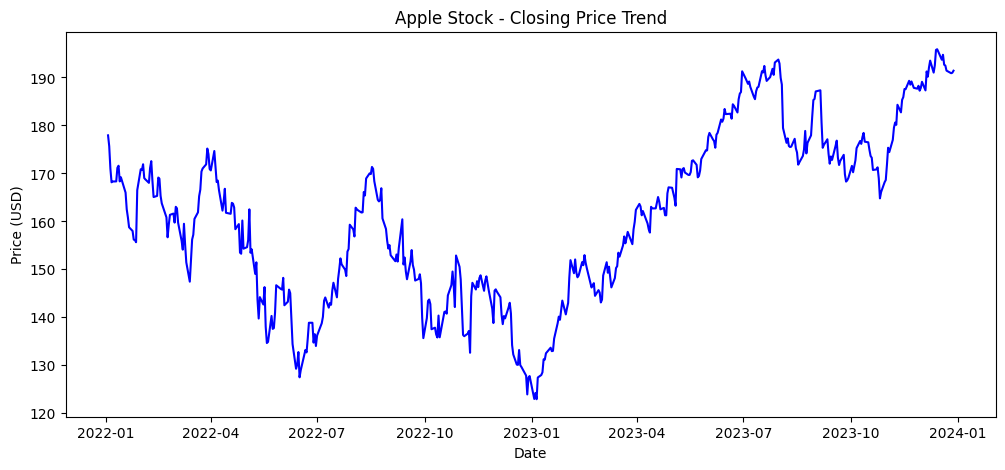

In [4]:
# Stock price ka trend dikhana
plt.figure(figsize=(12, 5))
plt.plot(df['Close'], color='blue')
plt.title("Apple Stock - Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

In [5]:
# Model train karna
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.9178384627133749
MSE: 5.713683204643989


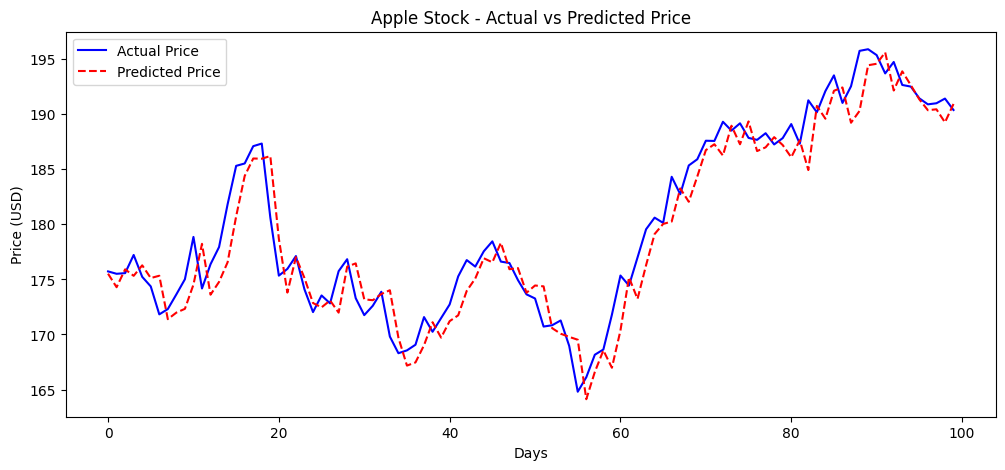

In [6]:
# Actual vs Predicted graph
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual Price', color='blue')
plt.plot(y_pred, label='Predicted Price', color='red', linestyle='--')
plt.title("Apple Stock - Actual vs Predicted Price")
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

## Results aur Insights

- Apple stock ka 2022-2024 ka data use kiya
- Linear Regression model ne next day ki price predict ki
- Open, High, Low aur Volume features use kiye
- Actual vs Predicted graph se model ka trend clearly dikh raha hai